In [41]:
##PASO 1

In [42]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
from datetime import datetime, timedelta
from statsmodels.stats.proportion import proportions_ztest

In [43]:
#Cargar el dataset
logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

In [44]:
##PASO 2

In [45]:
print(logs.info())
print()
print(logs.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None

                 EventName         DeviceIDHash  EventTimestamp  ExpId
0         MainScreenAppear  4575588528974610257      1564029816    246
1         MainScreenAppear  7416695313311560658      1564053102    246
2  PaymentScreenSuccessful  3518123091307005509      1564054127    248
3         CartScreenAppear  3518123091307005509      1564054127    248
4  PaymentScreenSuccessful  6217807653094995999      1564055322    248
5         CartScreenAppear  6217807653094995999      1564055323    248
6       OffersScreenAppear  8351860793733343758      1564066242    

In [46]:
print("=== INFORMACIÓN GENERAL ===")
print(f"Forma del dataset: {logs.shape}")
print(f"Columnas: {list(logs.columns)}")
print()

# Información detallada de cada columna
print("=== INFORMACIÓN DE COLUMNAS ===")
logs.info()
print()

# Estadísticas básicas
print("=== ESTADÍSTICAS BÁSICAS ===")
logs.describe(include='all')

=== INFORMACIÓN GENERAL ===
Forma del dataset: (244126, 4)
Columnas: ['EventName', 'DeviceIDHash', 'EventTimestamp', 'ExpId']

=== INFORMACIÓN DE COLUMNAS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB

=== ESTADÍSTICAS BÁSICAS ===


,EventName,DeviceIDHash,EventTimestamp,ExpId
count,244126,2.441260e+05,2.441260e+05,244126.000000
unique,5,NaN,NaN,NaN
top,MainScreenAppear,NaN,NaN,NaN
freq,119205,NaN,NaN,NaN
mean,NaN,4.627568e+18,1.564914e+09,247.022296
std,NaN,2.642425e+18,1.771343e+05,0.824434
min,NaN,6.888747e+15,1.564030e+09,246.000000
25%,NaN,2.372212e+18,1.564757e+09,246.000000
50%,NaN,4.623192e+18,1.564919e+09,247.000000
75%,NaN,6.932517e+18,1.565075e+09,248.000000


In [47]:
# Cambiar el nombre de las columnas
logs.columns = ['event_name', 'user_id', 'date_hour', 'exp_id']

# Verificar los cambios
print("=== COLUMNAS RENOMBRADAS ===")
print(f"Nuevas columnas: {list(logs.columns)}")
print()

# Ver los datos con los nuevos nombres
logs.head()

=== COLUMNAS RENOMBRADAS ===
Nuevas columnas: ['event_name', 'user_id', 'date_hour', 'exp_id']



,event_name,user_id,date_hour,exp_id
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [48]:
# Verificar información general del dataset
print("=== INFORMACIÓN GENERAL ===")
print(f"Forma del dataset: {logs.shape}")
print()

# Verificar tipos de datos
print("=== TIPOS DE DATOS ===")
print(logs.dtypes)
print()

# Verificar información detallada
logs.info()

=== INFORMACIÓN GENERAL ===
Forma del dataset: (244126, 4)

=== TIPOS DE DATOS ===
event_name    object
user_id        int64
date_hour      int64
exp_id         int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   event_name  244126 non-null  object
 1   user_id     244126 non-null  int64 
 2   date_hour   244126 non-null  int64 
 3   exp_id      244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [49]:
# Verificar valores ausentes
print("=== VALORES AUSENTES ===")
print("Valores nulos por columna:")
print(logs.isnull().sum())
print()

# Porcentaje de valores ausentes
print("Porcentaje de valores ausentes:")
print((logs.isnull().sum() / len(logs) * 100).round(2))

=== VALORES AUSENTES ===
Valores nulos por columna:
event_name    0
user_id       0
date_hour     0
exp_id        0
dtype: int64

Porcentaje de valores ausentes:
event_name    0.0
user_id       0.0
date_hour     0.0
exp_id        0.0
dtype: float64


In [50]:
# Verificar valores únicos en cada columna
print("=== VALORES ÚNICOS ===")
for col in logs.columns:
    print(f"\n{col}:")
    print(f"  Valores únicos: {logs[col].nunique()}")
    if logs[col].nunique() < 20:
        print(f"  Valores: {sorted(logs[col].unique())}")
    else:
        print(f"  Muestra: {sorted(logs[col].unique())[:10]}")

=== VALORES ÚNICOS ===

event_name:
  Valores únicos: 5
  Valores: ['CartScreenAppear', 'MainScreenAppear', 'OffersScreenAppear', 'PaymentScreenSuccessful', 'Tutorial']

user_id:
  Valores únicos: 7551
  Muestra: [6888746892508752, 6909561520679493, 6922444491712477, 7435777799948366, 7702139951469979, 8486814028069281, 8740973466195562, 9841258664663090, 12692216027168046, 15708180189885246]

date_hour:
  Valores únicos: 176654
  Muestra: [1564029816, 1564053102, 1564054127, 1564055322, 1564055323, 1564066242, 1564085677, 1564086702, 1564112112, 1564119214]

exp_id:
  Valores únicos: 3
  Valores: [246, 247, 248]


In [51]:
# Convertir date_hour de int64 a datetime
logs['date_hour'] = pd.to_datetime(logs['date_hour'], unit='s')
print(logs.dtypes)

event_name            object
user_id                int64
date_hour     datetime64[ns]
exp_id                 int64
dtype: object


In [52]:
print("Eventos únicos:")
print(logs['event_name'].value_counts())
print("Distribución de grupos experimentales:")
print(logs['exp_id'].value_counts())
print("Rango de fechas:")
print(f"Fecha mínima: {logs['date_hour'].min()}")
print(f"Fecha máxima: {logs['date_hour'].max()}")
print(f"Período total: {logs['date_hour'].max() - logs['date_hour'].min()}")

Eventos únicos:
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: event_name, dtype: int64
Distribución de grupos experimentales:
248    85747
246    80304
247    78075
Name: exp_id, dtype: int64
Rango de fechas:
Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17
Período total: 13 days 16:31:41


In [53]:
#Agregar una columna con solo la fecha
logs['date'] = logs['date_hour'].dt.date
logs.head()

,event_name,user_id,date_hour,exp_id,date
0,MainScreenAppear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,MainScreenAppear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,CartScreenAppear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


In [54]:
##PASO 3

In [55]:
# Análisis completo de eventos
print("=== ANÁLISIS DE EVENTOS ===")
print(f"Total de eventos: {len(logs)}")
print(f"Tipos de eventos únicos: {logs['event_name'].nunique()}")
print("\nDistribución por tipo de evento:")
distribucion = logs['event_name'].value_counts()
print(distribucion)

print("\nPorcentaje por tipo de evento:")
porcentajes = (logs['event_name'].value_counts() / len(logs) * 100).round(2)
print(porcentajes)

=== ANÁLISIS DE EVENTOS ===
Total de eventos: 244126
Tipos de eventos únicos: 5

Distribución por tipo de evento:
MainScreenAppear           119205
OffersScreenAppear          46825
CartScreenAppear            42731
PaymentScreenSuccessful     34313
Tutorial                     1052
Name: event_name, dtype: int64

Porcentaje por tipo de evento:
MainScreenAppear           48.83
OffersScreenAppear         19.18
CartScreenAppear           17.50
PaymentScreenSuccessful    14.06
Tutorial                    0.43
Name: event_name, dtype: float64


MainScreenAppear: Cada vez que alguien abre la app
OffersScreenAppear: Cuando ven las ofertas disponibles
CartScreenAppear: Cuando van al carrito de compras
PaymentScreenSuccessful: Cuando completan una compra exitosa
Tutorial: Cuando ven el tutorial de la app

In [56]:
# Número de usuarios en los registros
# Conteo de usuarios únicos
usuarios_unicos = logs['user_id'].nunique()
print(f"Total de usuarios únicos: {usuarios_unicos}")

# Promedio de eventos por usuario
promedio_eventos = len(logs) / usuarios_unicos
print(f"Promedio de eventos por usuario: {promedio_eventos:.1f}")

Total de usuarios únicos: 7551
Promedio de eventos por usuario: 32.3


In [57]:
# Análisis del período temporal
print("=== ANÁLISIS TEMPORAL ===")
fecha_min = logs['date_hour'].min()
fecha_max = logs['date_hour'].max()
periodo_total = fecha_max - fecha_min

print(f"Fecha mínima: {fecha_min}")
print(f"Fecha máxima: {fecha_max}")
print(f"Período total: {periodo_total}")
print(f"Días totales: {periodo_total.days}")

=== ANÁLISIS TEMPORAL ===
Fecha mínima: 2019-07-25 04:43:36
Fecha máxima: 2019-08-07 21:15:17
Período total: 13 days 16:31:41
Días totales: 13


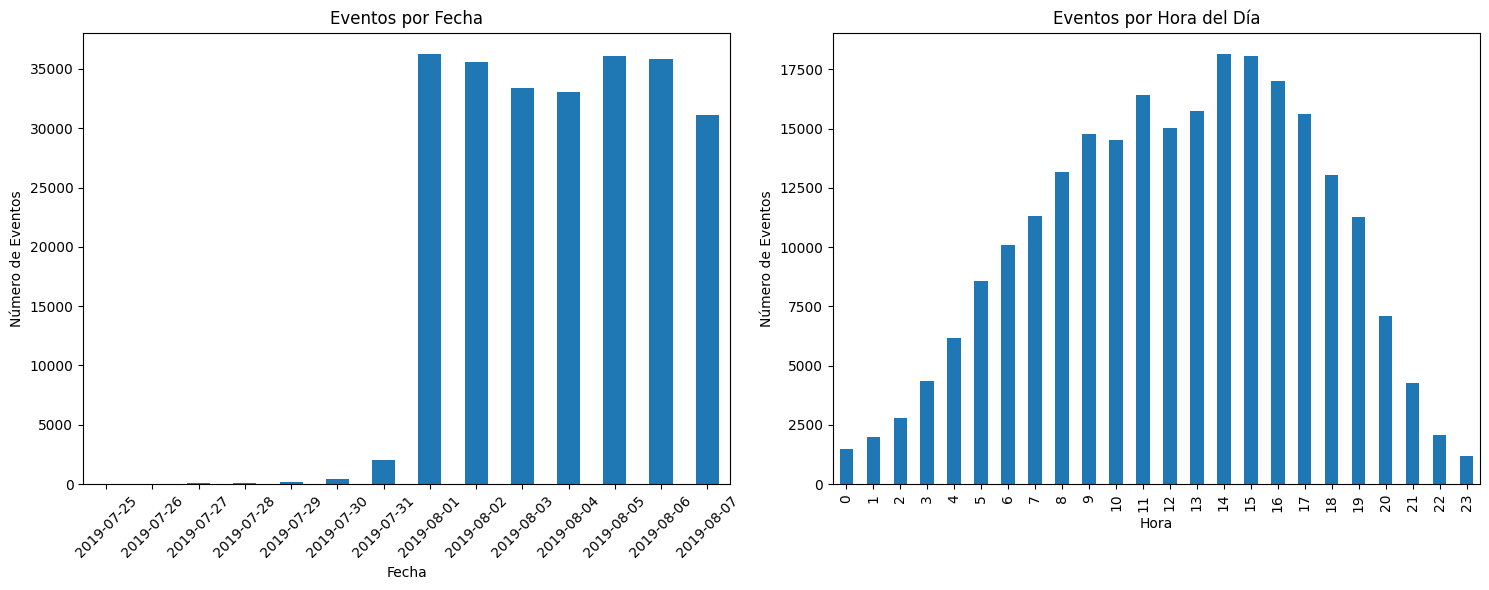

In [58]:
# Histograma por fecha
plt.figure(figsize=(15, 6))

# Por fecha
plt.subplot(1, 2, 1)
eventos_por_fecha = logs['date'].value_counts().sort_index()
eventos_por_fecha.plot(kind='bar')
plt.title('Eventos por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)

# Por hora del día
plt.subplot(1, 2, 2)
logs['hora'] = logs['date_hour'].dt.hour
eventos_por_hora = logs['hora'].value_counts().sort_index()
eventos_por_hora.plot(kind='bar')
plt.title('Eventos por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Eventos')

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Excelente trabajo tanto graficando la distribución de los eventos como de tu decisión de hacer el filtrado de datos. Tal como dices, los datos antes del 1 de agosto del 2019 parecen estar incompletos, lo cual los hace muy poco útiles para el análisis de embudo e incluso podrían conducir a interpretaciones imprecisas.
</div>

Eventos por día:
         date  eventos
0  2019-07-25        9
1  2019-07-26       31
2  2019-07-27       55
3  2019-07-28      105
4  2019-07-29      184
5  2019-07-30      413
6  2019-07-31     2031
7  2019-08-01    36229
8  2019-08-02    35606
9  2019-08-03    33351
10 2019-08-04    33033
11 2019-08-05    36113
12 2019-08-06    35822
13 2019-08-07    31144


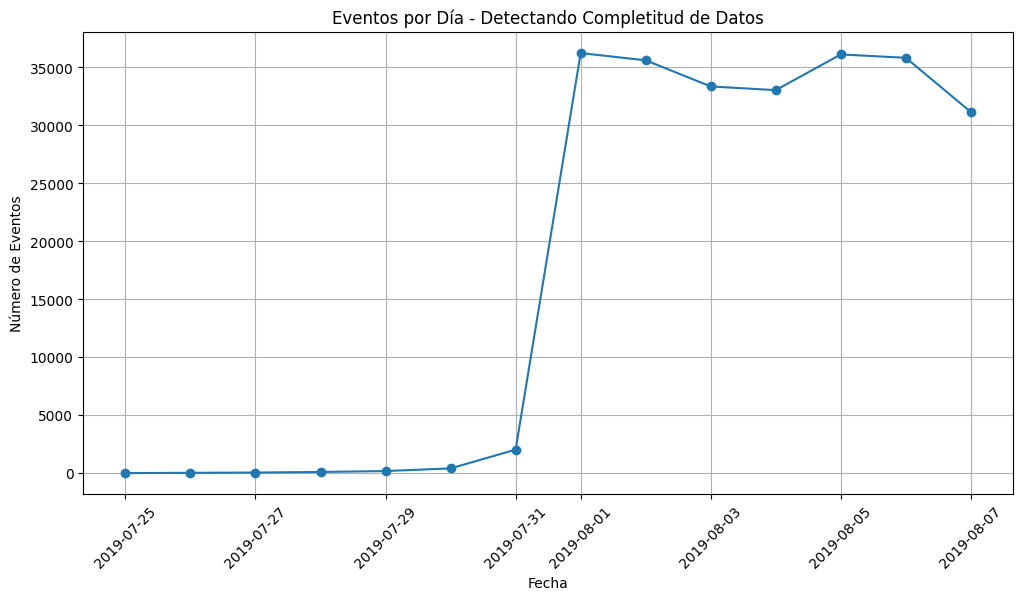

In [59]:
# Análisis de completitud de datos
eventos_diarios = logs.groupby('date').size().reset_index(name='eventos')
eventos_diarios['date'] = pd.to_datetime(eventos_diarios['date'])

print("Eventos por día:")
print(eventos_diarios)

# Visualizar la completitud
plt.figure(figsize=(12, 6))
plt.plot(eventos_diarios['date'], eventos_diarios['eventos'], marker='o')
plt.title('Eventos por Día - Detectando Completitud de Datos')
plt.xlabel('Fecha')
plt.ylabel('Número de Eventos')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Podemos observar que antes del 25 de julio los eventos eran muy bajos o nulos, por lo tanto, se descarta esa fecha para atrás para hacer el análisis.

In [60]:
# Encontrar el período con datos completos
umbral_minimo = eventos_diarios['eventos'].quantile(0.25)  # 25% más bajo
dias_completos = eventos_diarios[eventos_diarios['eventos'] >= umbral_minimo]

print(f"Umbral mínimo de eventos por día: {umbral_minimo:.0f}")
print(f"Primer día con datos completos: {dias_completos['date'].min().date()}")
print(f"Último día con datos completos: {dias_completos['date'].max().date()}")

Umbral mínimo de eventos por día: 125
Primer día con datos completos: 2019-07-29
Último día con datos completos: 2019-08-07


In [61]:
# Análisis del impacto de excluir datos incompletos
print("=== ANÁLISIS DE PÉRDIDA DE DATOS ===")

# Definir la fecha de corte (29 de julio)
fecha_corte = pd.to_datetime('2019-07-29').date()

# Datos que se van a excluir (antes del 29 de julio)
datos_excluidos = logs[logs['date'] < fecha_corte]
datos_completos = logs[logs['date'] >= fecha_corte]

print(f"Fecha de corte: {fecha_corte}")
print()

# Análisis de eventos perdidos
eventos_perdidos = len(datos_excluidos)
eventos_totales = len(logs)
porcentaje_eventos_perdidos = (eventos_perdidos / eventos_totales) * 100

print("=== EVENTOS ===")
print(f"Eventos totales: {eventos_totales:,}")
print(f"Eventos perdidos: {eventos_perdidos:,}")
print(f"Eventos conservados: {len(datos_completos):,}")
print(f"Porcentaje de eventos perdidos: {porcentaje_eventos_perdidos:.2f}%")
print()

# Análisis de usuarios perdidos
usuarios_perdidos = datos_excluidos['user_id'].nunique()
usuarios_totales = logs['user_id'].nunique()
usuarios_conservados = datos_completos['user_id'].nunique()
porcentaje_usuarios_perdidos = (usuarios_perdidos / usuarios_totales) * 100

print("=== USUARIOS ===")
print(f"Usuarios totales: {usuarios_totales:,}")
print(f"Usuarios perdidos: {usuarios_perdidos:,}")
print(f"Usuarios conservados: {usuarios_conservados:,}")
print(f"Porcentaje de usuarios perdidos: {porcentaje_usuarios_perdidos:.2f}%")


=== ANÁLISIS DE PÉRDIDA DE DATOS ===
Fecha de corte: 2019-07-29

=== EVENTOS ===
Eventos totales: 244,126
Eventos perdidos: 200
Eventos conservados: 243,926
Porcentaje de eventos perdidos: 0.08%

=== USUARIOS ===
Usuarios totales: 7,551
Usuarios perdidos: 137
Usuarios conservados: 7,548
Porcentaje de usuarios perdidos: 1.81%


Viendo los resultados con un 8% de los datos perdidos vana tener una significancia minuma aen el analisis pero ayudan a nos generar mucha dispersion los datos.

In [62]:
# Paso 1: Crear el dataset filtrado (datos completos desde 29 de julio)
fecha_corte = pd.to_datetime('2019-07-29').date()
logs_filtrado = logs[logs['date'] >= fecha_corte].copy()

print("=== VERIFICACIÓN DE GRUPOS EXPERIMENTALES ===")
print(f"Datos filtrados desde: {fecha_corte}")
print(f"Total de eventos en datos filtrados: {len(logs_filtrado):,}")
print()

# Paso 2: Verificar qué grupos experimentales están presentes
print("=== GRUPOS EXPERIMENTALES DISPONIBLES ===")
grupos_disponibles = logs_filtrado['exp_id'].unique()
print(f"Grupos encontrados: {sorted(grupos_disponibles)}")
print()

# Paso 3: Contar usuarios por grupo experimental
print("=== USUARIOS POR GRUPO EXPERIMENTAL ===")
usuarios_por_grupo = logs_filtrado.groupby('exp_id')['user_id'].nunique().sort_index()

for grupo in usuarios_por_grupo.index:
    cantidad = usuarios_por_grupo[grupo]
    print(f"Grupo {grupo}: {cantidad:,} usuarios únicos")


print()

# Paso 4: Verificar si tenemos los 3 grupos esperados
grupos_esperados = [246, 247, 248]  # Basado en tu análisis anterior
grupos_faltantes = set(grupos_esperados) - set(grupos_disponibles)

if len(grupos_faltantes) == 0:
    print("✅ ¡PERFECTO! hay usuarios de los 3 grupos experimentales")
else:
    print(f"⚠️  ATENCIÓN: Faltan los grupos: {list(grupos_faltantes)}")


=== VERIFICACIÓN DE GRUPOS EXPERIMENTALES ===
Datos filtrados desde: 2019-07-29
Total de eventos en datos filtrados: 243,926

=== GRUPOS EXPERIMENTALES DISPONIBLES ===
Grupos encontrados: [246, 247, 248]

=== USUARIOS POR GRUPO EXPERIMENTAL ===
Grupo 246: 2,487 usuarios únicos
Grupo 247: 2,520 usuarios únicos
Grupo 248: 2,541 usuarios únicos

✅ ¡PERFECTO! hay usuarios de los 3 grupos experimentales


In [63]:
##PASO 4 Estudiar el embudo de eventos


In [64]:
# Analizar eventos y su frecuencia
print("=== ANÁLISIS DE EVENTOS Y FRECUENCIA ===")

# Contar cada tipo de evento
eventos_frecuencia = logs_filtrado['event_name'].value_counts()
print("Eventos ordenados por frecuencia (de mayor a menor):")
print(eventos_frecuencia)
print()

# Calcular porcentajes
eventos_porcentaje = (eventos_frecuencia / len(logs_filtrado) * 100).round(2)
print("Porcentaje de cada evento:")
print(eventos_porcentaje)
print()

# Crear una tabla combinada más clara
tabla_eventos = pd.DataFrame({
    'Evento': eventos_frecuencia.index,
    'Frecuencia': eventos_frecuencia.values,
    'Porcentaje': eventos_porcentaje.values
})
print("=== TABLA RESUMEN ===")
for i, row in tabla_eventos.iterrows():
    print(f"{row['Evento']:25} | {row['Frecuencia']:8,} eventos | {row['Porcentaje']:5.1f}%")

=== ANÁLISIS DE EVENTOS Y FRECUENCIA ===
Eventos ordenados por frecuencia (de mayor a menor):
MainScreenAppear           119093
OffersScreenAppear          46795
CartScreenAppear            42695
PaymentScreenSuccessful     34295
Tutorial                     1048
Name: event_name, dtype: int64

Porcentaje de cada evento:
MainScreenAppear           48.82
OffersScreenAppear         19.18
CartScreenAppear           17.50
PaymentScreenSuccessful    14.06
Tutorial                    0.43
Name: event_name, dtype: float64

=== TABLA RESUMEN ===
MainScreenAppear          |  119,093 eventos |  48.8%
OffersScreenAppear        |   46,795 eventos |  19.2%
CartScreenAppear          |   42,695 eventos |  17.5%
PaymentScreenSuccessful   |   34,295 eventos |  14.1%
Tutorial                  |    1,048 eventos |   0.4%


In [65]:
# Encontrar usuarios únicos que realizaron cada acción
print("=== USUARIOS ÚNICOS POR EVENTO ===")

# Contar usuarios únicos por evento
usuarios_por_evento = logs_filtrado.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)
print("Usuarios únicos ordenados por cantidad (de mayor a menor):")
print(usuarios_por_evento)
print()

# Calcular proporción de usuarios que realizaron cada acción
total_usuarios = logs_filtrado['user_id'].nunique()
proporcion_usuarios = (usuarios_por_evento / total_usuarios * 100).round(2)

print(f"Total de usuarios únicos en el dataset: {total_usuarios:,}")
print()
print("Proporción de usuarios que realizaron cada acción:")
print(proporcion_usuarios)
print()

# Crear tabla combinada
tabla_usuarios = pd.DataFrame({
    'Evento': usuarios_por_evento.index,
    'Usuarios_Unicos': usuarios_por_evento.values,
    'Proporcion_Porcentaje': proporcion_usuarios.values
})

print("=== TABLA RESUMEN - USUARIOS ÚNICOS ===")
for i, row in tabla_usuarios.iterrows():
    print(f"{row['Evento']:25} | {row['Usuarios_Unicos']:5,} usuarios | {row['Proporcion_Porcentaje']:5.1f}%")

=== USUARIOS ÚNICOS POR EVENTO ===
Usuarios únicos ordenados por cantidad (de mayor a menor):
event_name
MainScreenAppear           7436
OffersScreenAppear         4612
CartScreenAppear           3749
PaymentScreenSuccessful    3547
Tutorial                    845
Name: user_id, dtype: int64

Total de usuarios únicos en el dataset: 7,548

Proporción de usuarios que realizaron cada acción:
event_name
MainScreenAppear           98.52
OffersScreenAppear         61.10
CartScreenAppear           49.67
PaymentScreenSuccessful    46.99
Tutorial                   11.20
Name: user_id, dtype: float64

=== TABLA RESUMEN - USUARIOS ÚNICOS ===
MainScreenAppear          | 7,436 usuarios |  98.5%
OffersScreenAppear        | 4,612 usuarios |  61.1%
CartScreenAppear          | 3,749 usuarios |  49.7%
PaymentScreenSuccessful   | 3,547 usuarios |  47.0%
Tutorial                  |   845 usuarios |  11.2%


In [66]:
# Definir la secuencia del embudo
funnel_steps = [
    'MainScreenAppear',
    'OffersScreenAppear', 
    'CartScreenAppear',
    'PaymentScreenSuccessful'
]

def calculate_funnel(data, steps):
    """
    Calcula el embudo de conversión
    """
    funnel_data = []
    
    for i, step in enumerate(steps):
        if i == 0:
            # Primer paso: todos los usuarios que realizaron este evento
            users_in_step = data[data['event_name'] == step]['user_id'].nunique()
        else:
            # Pasos siguientes: usuarios que hicieron el paso anterior Y este paso
            previous_users = data[data['event_name'] == steps[i-1]]['user_id'].unique()
            current_users = data[data['event_name'] == step]['user_id'].unique()
            users_in_step = len(set(previous_users) & set(current_users))
        
        funnel_data.append({
            'step': i + 1,
            'event_name': step,
            'users': users_in_step
        })
    
    return pd.DataFrame(funnel_data)

Realice un embudo de 4 pasos ya que la frecuencia y porcentaje de tutorial son bajos, además de ser un paso no necesariamente obligatorio para generar una compra o no completa, así que se verá como un evento separado.

In [67]:
def calculate_funnel_with_conversion(data, steps):
    """
    Calcula el embudo de conversión con tasas de conversión
    """
    funnel_data = []
    
    # Calcular usuarios únicos para cada paso
    for i, step in enumerate(steps):
        users_in_step = data[data['event_name'] == step]['user_id'].nunique()
        funnel_data.append({
            'step': i + 1,
            'event_name': step,
            'users': users_in_step
        })
    
    # Convertir a DataFrame
    funnel_df = pd.DataFrame(funnel_data)
    
    # Calcular tasas de conversión
    funnel_df['conversion_rate'] = 0.0
    funnel_df['retention_rate'] = 0.0
    
    for i in range(len(funnel_df)):
        if i == 0:
            # Primer paso: 100% de conversión (punto de partida)
            funnel_df.loc[i, 'conversion_rate'] = 100.0
            funnel_df.loc[i, 'retention_rate'] = 100.0
        else:
            # Tasa de conversión: usuarios actuales / usuarios del paso anterior
            current_users = funnel_df.loc[i, 'users']
            previous_users = funnel_df.loc[i-1, 'users']
            conversion = (current_users / previous_users) * 100
            funnel_df.loc[i, 'conversion_rate'] = round(conversion, 2)
            
            # Tasa de retención: usuarios actuales / usuarios del primer paso
            first_step_users = funnel_df.loc[0, 'users']
            retention = (current_users / first_step_users) * 100
            funnel_df.loc[i, 'retention_rate'] = round(retention, 2)
    
    return funnel_df

# Ejecutar el análisis del embudo con tu dataset logs_filtrado
funnel_results = calculate_funnel_with_conversion(logs_filtrado, funnel_steps)
print("=== EMBUDO DE CONVERSIÓN ===")
print(funnel_results)

=== EMBUDO DE CONVERSIÓN ===
   step               event_name  users  conversion_rate  retention_rate
0     1         MainScreenAppear   7436           100.00          100.00
1     2       OffersScreenAppear   4612            62.02           62.02
2     3         CartScreenAppear   3749            81.29           50.42
3     4  PaymentScreenSuccessful   3547            94.61           47.70


In [68]:
# Mostrar resultados de forma más clara
print("\n=== ANÁLISIS DETALLADO DEL EMBUDO ===")
for i, row in funnel_results.iterrows():
    print(f"Paso {row['step']}: {row['event_name']}")
    print(f"  👥 Usuarios: {row['users']:,}")
    print(f"  📈 Tasa de conversión: {row['conversion_rate']:.1f}%")
    print(f"  📊 Tasa de retención: {row['retention_rate']:.1f}%")
    print()


=== ANÁLISIS DETALLADO DEL EMBUDO ===
Paso 1: MainScreenAppear
  👥 Usuarios: 7,436
  📈 Tasa de conversión: 100.0%
  📊 Tasa de retención: 100.0%

Paso 2: OffersScreenAppear
  👥 Usuarios: 4,612
  📈 Tasa de conversión: 62.0%
  📊 Tasa de retención: 62.0%

Paso 3: CartScreenAppear
  👥 Usuarios: 3,749
  📈 Tasa de conversión: 81.3%
  📊 Tasa de retención: 50.4%

Paso 4: PaymentScreenSuccessful
  👥 Usuarios: 3,547
  📈 Tasa de conversión: 94.6%
  📊 Tasa de retención: 47.7%



# ¿En qué etapa pierdes más usuarios?
Según los resultados de mi embudo, en la etapa 2 OffersScreenAppear es donde se pierde la mayor cantidad de usuarios, exactamente un 38% de los usuarios. 

In [69]:
# Tasa de retención: usuarios actuales / usuarios del primer paso
last_step_users = funnel_results.loc[3, 'users']  # Paso 4: PaymentScreenSuccessful
first_step_users = funnel_results.loc[0, 'users']  # Paso 1: MainScreenAppear
retention = (last_step_users / first_step_users) * 100
print("Tasa de retención: usuarios actuales / usuarios del primer paso")
print(retention)

Tasa de retención: usuarios actuales / usuarios del primer paso
47.70037654653039


El 47.7% de los usuarios completa todo el viaje desde su primer evento hasta el pago
Esto significa que:

7,436 usuarios empezaron el viaje viendo la pantalla principal (MainScreenAppear)
3,547 usuarios completaron una compra exitosa (PaymentScreenSuccessful)
Tasa de conversión total: 47.7%

In [70]:
# paso 5

In [71]:
print()
# Paso 3: Contar usuarios por grupo experimental
print("=== USUARIOS POR GRUPO EXPERIMENTAL ===")
usuarios_por_grupo = logs_filtrado.groupby('exp_id')['user_id'].nunique().sort_index()

for grupo in usuarios_por_grupo.index:
    cantidad = usuarios_por_grupo[grupo]
    print(f"Grupo {grupo}: {cantidad:,} usuarios únicos")


=== USUARIOS POR GRUPO EXPERIMENTAL ===
Grupo 246: 2,487 usuarios únicos
Grupo 247: 2,520 usuarios únicos
Grupo 248: 2,541 usuarios únicos


In [72]:
# Filtrar solo los grupos 246 y 247 (grupos de control)
grupos_control = logs_filtrado[logs_filtrado['exp_id'].isin([246, 247])].copy()

print("=== VERIFICACIÓN DE GRUPOS DE CONTROL ===")
print(f"Total de eventos en grupos de control: {len(grupos_control):,}")
print("\nDistribución de usuarios por grupo:")
print(grupos_control['exp_id'].value_counts().sort_index())

=== VERIFICACIÓN DE GRUPOS DE CONTROL ===
Total de eventos en grupos de control: 158,236

Distribución de usuarios por grupo:
246    80229
247    78007
Name: exp_id, dtype: int64


In [73]:
# Calcular usuarios únicos por grupo de control
print("=== ANÁLISIS DE USUARIOS POR GRUPO DE CONTROL ===")
usuarios_246 = grupos_control[grupos_control['exp_id'] == 246]['user_id'].nunique()
usuarios_247 = grupos_control[grupos_control['exp_id'] == 247]['user_id'].nunique()

print(f"Grupo 246: {usuarios_246:,} usuarios únicos")
print(f"Grupo 247: {usuarios_247:,} usuarios únicos")
print(f"Diferencia: {abs(usuarios_246 - usuarios_247):,} usuarios")
print(f"Diferencia porcentual: {abs(usuarios_246 - usuarios_247) / max(usuarios_246, usuarios_247) * 100:.2f}%")

=== ANÁLISIS DE USUARIOS POR GRUPO DE CONTROL ===
Grupo 246: 2,487 usuarios únicos
Grupo 247: 2,520 usuarios únicos
Diferencia: 33 usuarios
Diferencia porcentual: 1.31%


In [74]:
def calcular_conversion_por_grupo(data, grupo_id, funnel_steps):
    """Calcula tasas de conversión para un grupo específico"""
    grupo_data = data[data['exp_id'] == grupo_id]
    
    conversiones = {}
    for i, step in enumerate(funnel_steps):
        usuarios_step = grupo_data[grupo_data['event_name'] == step]['user_id'].nunique()
        conversiones[step] = usuarios_step
    
    return conversiones

# Calcular conversiones para ambos grupos
funnel_steps = ['MainScreenAppear', 'OffersScreenAppear', 'CartScreenAppear', 'PaymentScreenSuccessful']

conversiones_246 = calcular_conversion_por_grupo(grupos_control, 246, funnel_steps)
conversiones_247 = calcular_conversion_por_grupo(grupos_control, 247, funnel_steps)

print("=== CONVERSIONES POR GRUPO ===")
print("Grupo 246:", conversiones_246)
print("Grupo 247:", conversiones_247)

=== CONVERSIONES POR GRUPO ===
Grupo 246: {'MainScreenAppear': 2454, 'OffersScreenAppear': 1545, 'CartScreenAppear': 1270, 'PaymentScreenSuccessful': 1202}
Grupo 247: {'MainScreenAppear': 2482, 'OffersScreenAppear': 1529, 'CartScreenAppear': 1240, 'PaymentScreenSuccessful': 1160}


In [75]:
# Encontrar el evento más popular en los grupos de control
eventos_populares = grupos_control['event_name'].value_counts()
print("=== EVENTOS MÁS POPULARES EN GRUPOS DE CONTROL ===")
print(eventos_populares)

evento_mas_popular = eventos_populares.index[0]
print(f"\nEvento más popular: {evento_mas_popular}")

=== EVENTOS MÁS POPULARES EN GRUPOS DE CONTROL ===
MainScreenAppear           77911
OffersScreenAppear         30228
CartScreenAppear           27367
PaymentScreenSuccessful    22060
Tutorial                     670
Name: event_name, dtype: int64

Evento más popular: MainScreenAppear


In [76]:
# Calcular proporciones para el evento más popular
def calcular_proporcion_evento(data, grupo_id, evento):
    """Calcula la proporción de usuarios que realizaron un evento específico"""
    grupo_data = data[data['exp_id'] == grupo_id]
    
    # Total de usuarios únicos en el grupo
    total_usuarios = grupo_data['user_id'].nunique()
    
    # Usuarios que realizaron el evento específico
    usuarios_evento = grupo_data[grupo_data['event_name'] == evento]['user_id'].nunique()
    
    # Proporción
    proporcion = usuarios_evento / total_usuarios
    
    return usuarios_evento, total_usuarios, proporcion

# Calcular para ambos grupos
usuarios_246, total_246, prop_246 = calcular_proporcion_evento(grupos_control, 246, evento_mas_popular)
usuarios_247, total_247, prop_247 = calcular_proporcion_evento(grupos_control, 247, evento_mas_popular)

print(f"Grupo 246: {usuarios_246}/{total_246} = {prop_246:.4f} ({prop_246*100:.2f}%)")
print(f"Grupo 247: {usuarios_247}/{total_247} = {prop_247:.4f} ({prop_247*100:.2f}%)")

Grupo 246: 2454/2487 = 0.9867 (98.67%)
Grupo 247: 2482/2520 = 0.9849 (98.49%)


In [79]:
# Comparación estadística entre los grupos
def test_proporciones(usuarios_1, total_1, usuarios_2, total_2, alpha=0.05):
    """Realiza test de proporciones entre dos grupos"""
    stat, p_value = proportions_ztest([usuarios_1, usuarios_2], [total_1, total_2])
    es_significativo = p_value < alpha
    return stat, p_value, es_significativo

# Usar la función e imprimir resultados
stat, p_value, es_significativo = test_proporciones(usuarios_246, total_246, usuarios_247, total_247)

print(f"P-value: {p_value:.6f}")
print(f"¿Significativo? {'SÍ' if es_significativo else 'NO'}")




P-value: 0.588010
¿Significativo? NO


In [82]:
# Significancia para el grupo de fuentes alternativas
# Analizar grupo experimental (248)
def analizar_grupo_experimental(data, grupo_experimental=248):
    """Analiza las proporciones del grupo experimental para todos los eventos"""
    grupo_exp = data[data['exp_id'] == grupo_experimental]
    
    # Obtener todos los eventos únicos
    eventos = data['event_name'].unique()
    
    resultados_exp = {}
    
    for evento in eventos:
        usuarios_evento, total_usuarios, proporcion = calcular_proporcion_evento(data, grupo_experimental, evento)
        resultados_exp[evento] = {
            'usuarios': usuarios_evento,
            'total': total_usuarios,
            'proporcion': proporcion
        }
        
    return resultados_exp

# Ejecutar análisis
resultados_248 = analizar_grupo_experimental(logs_filtrado)
print("=== RESULTADOS GRUPO 248 (FUENTES NUEVAS) ===")
for evento, datos in resultados_248.items():
    proporcion_pct = datos['proporcion'] * 100
    print(f"{evento}: {datos['usuarios']}/{datos['total']} = {proporcion_pct:.2f}%")

=== RESULTADOS GRUPO 248 (FUENTES NUEVAS) ===
MainScreenAppear: 2500/2541 = 98.39%
CartScreenAppear: 1239/2541 = 48.76%
PaymentScreenSuccessful: 1185/2541 = 46.64%
OffersScreenAppear: 1538/2541 = 60.53%
Tutorial: 282/2541 = 11.10%


El grupo 246 sí tiene la tasa más alta (48.31%)
El grupo 248 (46.64%) tiene una tasa ligeramente mayor que el grupo 247 (46.03%)

In [83]:
# COMPARACIÓN 1: Grupo 248 vs Grupo 246 (individual)
print("=== COMPARACIÓN 1: GRUPO 248 vs GRUPO 246 ===")
usuarios_248_payment, total_248, prop_248 = calcular_proporcion_evento(logs_filtrado, 248, 'PaymentScreenSuccessful')
usuarios_246_payment, total_246, prop_246 = calcular_proporcion_evento(logs_filtrado, 246, 'PaymentScreenSuccessful')

stat_248_246, p_value_248_246, significativo_248_246 = test_proporciones(
    usuarios_248_payment, total_248, usuarios_246_payment, total_246
)

print(f"Grupo 248: {usuarios_248_payment}/{total_248} = {prop_248*100:.2f}%")
print(f"Grupo 246: {usuarios_246_payment}/{total_246} = {prop_246*100:.2f}%")
print(f"P-value: {p_value_248_246:.6f}")
print(f"¿Significativo? {'SÍ' if significativo_248_246 else 'NO'}")
print()

# COMPARACIÓN 2: Grupo 248 vs Grupo 247 (individual)
print("=== COMPARACIÓN 2: GRUPO 248 vs GRUPO 247 ===")
usuarios_247_payment, total_247, prop_247 = calcular_proporcion_evento(logs_filtrado, 247, 'PaymentScreenSuccessful')

stat_248_247, p_value_248_247, significativo_248_247 = test_proporciones(
    usuarios_248_payment, total_248, usuarios_247_payment, total_247
)

print(f"Grupo 248: {usuarios_248_payment}/{total_248} = {prop_248*100:.2f}%")
print(f"Grupo 247: {usuarios_247_payment}/{total_247} = {prop_247*100:.2f}%")
print(f"P-value: {p_value_248_247:.6f}")
print(f"¿Significativo? {'SÍ' if significativo_248_247 else 'NO'}")

=== COMPARACIÓN 1: GRUPO 248 vs GRUPO 246 ===
Grupo 248: 1185/2541 = 46.64%
Grupo 246: 1202/2487 = 48.33%
P-value: 0.228522
¿Significativo? NO

=== COMPARACIÓN 2: GRUPO 248 vs GRUPO 247 ===
Grupo 248: 1185/2541 = 46.64%
Grupo 247: 1160/2520 = 46.03%
P-value: 0.666873
¿Significativo? NO


In [84]:
# Combinar grupos de control 246 y 247
grupos_control_combinados = logs_filtrado[logs_filtrado['exp_id'].isin([246, 247])].copy()

print("=== GRUPOS DE CONTROL COMBINADOS ===")
print(f"Total de usuarios en grupos combinados: {grupos_control_combinados['user_id'].nunique():,}")
print(f"Grupo 246: {logs_filtrado[logs_filtrado['exp_id'] == 246]['user_id'].nunique():,} usuarios")
print(f"Grupo 247: {logs_filtrado[logs_filtrado['exp_id'] == 247]['user_id'].nunique():,} usuarios")
print(f"Total combinado: {grupos_control_combinados['user_id'].nunique():,} usuarios")

=== GRUPOS DE CONTROL COMBINADOS ===
Total de usuarios en grupos combinados: 5,007
Grupo 246: 2,487 usuarios
Grupo 247: 2,520 usuarios
Total combinado: 5,007 usuarios


In [85]:
# Calcular conversiones para grupo experimental (248)
usuarios_248_payment = logs_filtrado[(logs_filtrado['exp_id'] == 248) & 
                                   (logs_filtrado['event_name'] == 'PaymentScreenSuccessful')]['user_id'].nunique()
total_248 = logs_filtrado[logs_filtrado['exp_id'] == 248]['user_id'].nunique()

# Calcular conversiones para grupos de control combinados
usuarios_control_payment = grupos_control_combinados[grupos_control_combinados['event_name'] == 'PaymentScreenSuccessful']['user_id'].nunique()
total_control = grupos_control_combinados['user_id'].nunique()

print("=== COMPARACIÓN: EXPERIMENTAL vs CONTROL COMBINADO ===")
print(f"Grupo 248 (experimental): {usuarios_248_payment}/{total_248} = {(usuarios_248_payment/total_248)*100:.2f}%")
print(f"Control combinado (246+247): {usuarios_control_payment}/{total_control} = {(usuarios_control_payment/total_control)*100:.2f}%")

=== COMPARACIÓN: EXPERIMENTAL vs CONTROL COMBINADO ===
Grupo 248 (experimental): 1185/2541 = 46.64%
Control combinado (246+247): 2362/5007 = 47.17%


In [86]:
# COMPARACIÓN FINAL: Grupo 248 vs Control Combinado
print("=== COMPARACIÓN FINAL: EXPERIMENTAL vs CONTROL COMBINADO ===")

# Realizar el test estadístico
stat_final, p_value_final, significativo_final = test_proporciones(
    usuarios_248_payment, total_248, usuarios_control_payment, total_control
)

print(f"Grupo 248 (experimental): {usuarios_248_payment}/{total_248} = {(usuarios_248_payment/total_248)*100:.2f}%")
print(f"Control combinado (246+247): {usuarios_control_payment}/{total_control} = {(usuarios_control_payment/total_control)*100:.2f}%")
print(f"Diferencia: {((usuarios_248_payment/total_248) - (usuarios_control_payment/total_control))*100:.2f} puntos porcentuales")
print(f"Z-statistic: {stat_final:.4f}")
print(f"P-value: {p_value_final:.6f}")
print(f"¿Significativo? {'SÍ' if significativo_final else 'NO'}")

# Interpretación del resultado
if significativo_final:
    if (usuarios_248_payment/total_248) > (usuarios_control_payment/total_control):
        print("\n🎉 RESULTADO: Las nuevas fuentes de tráfico MEJORAN significativamente las conversiones")
    else:
        print("\n⚠️ RESULTADO: Las nuevas fuentes de tráfico EMPEORAN significativamente las conversiones")
else:
    print("\n📊 RESULTADO: NO hay diferencia estadísticamente significativa entre las fuentes")

=== COMPARACIÓN FINAL: EXPERIMENTAL vs CONTROL COMBINADO ===
Grupo 248 (experimental): 1185/2541 = 46.64%
Control combinado (246+247): 2362/5007 = 47.17%
Diferencia: -0.54 puntos porcentuales
Z-statistic: -0.4432
P-value: 0.657622
¿Significativo? NO

📊 RESULTADO: NO hay diferencia estadísticamente significativa entre las fuentes


Conclusión: Los análisis y pruebas estadísticas de los 3 grupos nos muestran que no hay diferencias significativas, incluso al combinarlos, da un porcentaje un poco menor, nada relevante, que no aumenta la retención y tampoco disminuye.

# Con un nivel de significancia estadística de 0.1
El análisis demuestra que NO hay diferencia estadísticamente significativa entre las fuentes de tráfico, y llegamos a esta conclusión porque:
1. Los p-values son altos (todos > 20%)
2. La corrección por múltiples comparaciones no afecta el resultado
3. Las diferencias observadas son muy pequeñas

Por último recomendación a la compañía y su equipo de marketing, es que no implementen nuevas fuentes de tráfico ya que estadísticamente no generan un valor comprobable y por el contrario gastan recursos de la compañía generando nuevas fuentes y estrategias.  